### Essas são minhas anotações e consultas as IA sobre regressão linear

### 1 Ajustar o modelo

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import pandas as pd
import statsmodels.api as sm

# exemplo
df = pd.DataFrame({
    'x1': [1, 2, 3, 4, 5],
    'x2': [2, 1, 3, 5, 4],
    'y':  [2, 3, 5, 7, 8]
})

X = sm.add_constant(df[['x1', 'x2']])
y = df['y']

model = sm.OLS(y, X).fit()

### 2 Visão Geral - 1° Diagnóstico

In [5]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.305e+30
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           7.66e-31
Time:                        21:59:21   Log-Likelihood:                 162.14
No. Observations:                   5   AIC:                            -318.3
Df Residuals:                       2   BIC:                            -319.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const               0   3.46e-15          0      1.0

### Aqui você já avalia:
coef → magnitude  
P>|t| → significância  
R-squared → explicação  
Adj. R-squared → ajuste penalizado  
F-statistic → modelo global

### 3. Avaliar coeficientes individualmente

In [11]:
print(model.params)      # betas
print("----------")
print(model.bse)         # erros padrão
print("----------")
print(model.pvalues)     # p-values
print("----------")
print(model.conf_int())  # intervalos de confiança

const    0.000000
x1       1.333333
x2       0.333333
dtype: float64
----------
const    3.457057e-15
x1       1.663277e-15
x2       1.663277e-15
dtype: float64
----------
const    1.000000e+00
x1       1.556151e-30
x2       2.489842e-29
dtype: float64
----------
                  0             1
const -1.487452e-14  1.487452e-14
x1     1.333333e+00  1.333333e+00
x2     3.333333e-01  3.333333e-01


### Critérios:
p-value < 0.05 → relevante  
IC não contém 0 → robusto

### 4. Avaliar qualidade global

In [13]:
print("R² ", model.rsquared)
print("----------")
print("R² Ajustado ",model.rsquared_adj)
print("----------")
print("F value ", model.fvalue)
print("----------")
print("F_pvalue ", model.f_pvalue)

R²  1.0
----------
R² Ajustado  1.0
----------
F value  1.3053035883538204e+30
----------
F_pvalue  7.661053021857903e-31


### 5. Avaliar erro de previsão

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred = model.predict(X)

rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print("RMSE ",rmse, "\nMAE ",mae)

RMSE  1.995932757225581e-15 
MAE  1.6875389974302379e-15


### 6. Diagnóstico dos resíduos

In [17]:
residuals = model.resid
fitted = model.fittedvalues

### 6.1 Homoscedasticidade (visual)

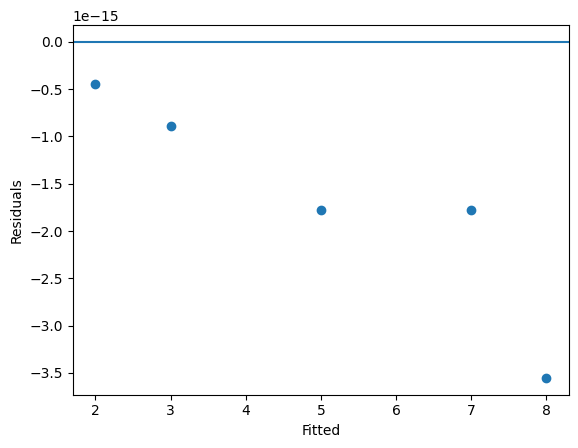

In [18]:
import matplotlib.pyplot as plt

plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.show()

Procure padrão → se houver, problema de variância

### 6.2 Normalidade dos erros

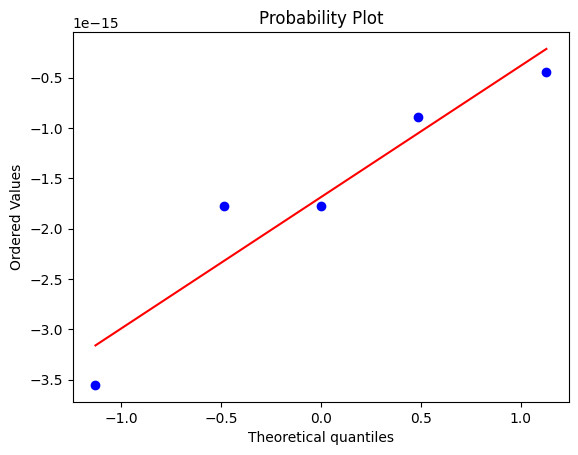

In [19]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

### 7. Multicolinearidade (importante)

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["variavel"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

  variavel       VIF
0    const  6.000000
1       x1  2.777778
2       x2  2.777778


Regra prática:  
VIF > 10 → problema sério

### 8. (Opcional) Padronizar para comparar coeficientes

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['x1', 'x2']])
X_scaled = sm.add_constant(X_scaled)

model_scaled = sm.OLS(y, X_scaled).fit()
print(model_scaled.params)

const    5.000000
x1       1.885618
x2       0.471405
dtype: float64


### Checklist final (o que você precisa olhar)
🔎 Coeficientes  
p-value < 0.05?  
sinal faz sentido? 

📊 Modelo  
R² alto o suficiente?  
F significativo? 

⚠️ Problemas  
resíduos têm padrão?  
normalidade ok? 
 
VIF alto?  
📉 Previsão  
RMSE aceitável?  

### Intuição operacional  

Você está respondendo 4 perguntas:  

As variáveis importam? → p-value  
O modelo explica bem? → R²  
Está bem especificado? → resíduos  
Prediz bem? → RMSE  

## Pipeline

In [ ]:
# --------------------------------------------------------------
# 1. IMPORTS E GERAÇÃO DE DADOS
# --------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset, het_breuschpagan, acorr_breusch_godfrey, normal_ad
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)

# Dados artificiais com relação não linear
n = 400
X1 = np.random.uniform(0, 10, n)
X2 = np.random.uniform(-5, 5, n)
eps = np.random.normal(0, 3, n)

# Relação verdadeira (não-linear)
Y = 5 + 2*X1 - 1.5*X2 + 0.4*(X1**2) + eps

df = pd.DataFrame({"Y": Y, "X1": X1, "X2": X2})


# --------------------------------------------------------------
# 2. EXPLORAÇÃO INICIAL
# --------------------------------------------------------------

print("\n=== Estatísticas descritivas ===")
print(df.describe())

sns.pairplot(df)
plt.show()


# --------------------------------------------------------------
# 3. TREINO / TESTE
# --------------------------------------------------------------

X = df[["X1", "X2"]]
y = df["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Adiciona intercepto
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)


# --------------------------------------------------------------
# 4. AJUSTE DO MODELO LINEAR
# --------------------------------------------------------------

modelo = sm.OLS(y_train, X_train_sm).fit()

print("\n=== Resultado do modelo inicial (possivelmente mal especificado) ===")
print(modelo.summary())


# --------------------------------------------------------------
# 5. DIAGNÓSTICOS DO MODELO
# --------------------------------------------------------------

# ---- 5.1 Teste RESET ----
reset = linear_reset(modelo, power=3, use_f=True)
print("\n=== RESET test ===")
print(reset)


# ---- 5.2 Análise de Resíduos ----
residuos = modelo.resid
ajustados = modelo.fittedvalues

plt.scatter(ajustados, residuos)
plt.axhline(0, color='red', linestyle='--')
plt.title("Resíduos vs Valores Ajustados")
plt.xlabel("Ajustados")
plt.ylabel("Resíduos")
plt.show()

sns.histplot(residuos, kde=True)
plt.title("Distribuição dos resíduos")
plt.show()


# ---- 5.3 Teste de heterocedasticidade (Breusch-Pagan) ----
bp_test = het_breuschpagan(residuos, modelo.model.exog)
print("\n=== Breusch-Pagan (Heterocedasticidade) ===")
print(f"LM Stat={bp_test[0]:.4f}, p-value={bp_test[1]:.4f}")


# ---- 5.4 Teste de autocorrelação (Breusch-Godfrey) ----
bg_test = acorr_breusch_godfrey(modelo, nlags=4)
print("\n=== Breusch-Godfrey (Autocorrelação) ===")
print(f"LM Stat={bg_test[0]:.4f}, p-value={bg_test[1]:.4f}")


# ---- 5.5 Teste de normalidade dos resíduos ----
ad_test = normal_ad(residuos)
print("\n=== Teste Anderson-Darling (Normalidade) ===")
print(f"Stat={ad_test[0]:.4f}, p-value={ad_test[1]:.4f}")


# ---- 5.6 VIF (multicolinearidade) ----
vif_df = pd.DataFrame()
vif_df["variavel"] = X_train.columns
vif_df["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

print("\n=== VIF ===")
print(vif_df)


# --------------------------------------------------------------
# 6. REFINAMENTO DO MODELO (INCLUINDO X1^2 POR CAUSA DO RESET)
# --------------------------------------------------------------

df["X1_2"] = df["X1"]**2

X = df[["X1", "X2", "X1_2"]]
y = df["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

modelo2 = sm.OLS(y_train, X_train_sm).fit()

print("\n=== Modelo refinado com X1^2 ===")
print(modelo2.summary())


# --------------------------------------------------------------
# 7. AVALIAÇÃO NO TESTE
# --------------------------------------------------------------

y_pred = modelo2.predict(X_test_sm)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== Avaliação no conjunto de teste ===")
print(f"RMSE = {rmse:.4f}")
print(f"MAE  = {mae:.4f}")
print(f"R²   = {r2:.4f}")


# --------------------------------------------------------------
# 8. VALIDAÇÃO CRUZADA
# --------------------------------------------------------------

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = []

for train_idx, test_idx in kf.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    X_tr_sm = sm.add_constant(X_tr)
    X_te_sm = sm.add_constant(X_te)

    m = sm.OLS(y_tr, X_tr_sm).fit()
    pred = m.predict(X_te_sm)

    rmse_scores.append(np.sqrt(mean_squared_error(y_te, pred)))

print("\n=== Validação Cruzada (RMSE por fold) ===")
print(rmse_scores)
print(f"RMSE médio = {np.mean(rmse_scores):.4f}")

## Sobre Intervalo de confiança dos preditores e da predição

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Generate synthetic linear data
np.random.seed(42)
n = 200
X = np.linspace(0, 10, n)
noise = np.random.normal(0, 2, n)
# True model: y = 3 + 1.5x
Y = 3 + 1.5*X + noise

# Prepare dataframe
X_df = pd.DataFrame({'x': X})
X_sm = sm.add_constant(X_df)

# Fit model
model = sm.OLS(Y, X_sm).fit()

# New points for prediction
grid = pd.DataFrame({'x': np.linspace(0, 10, 200)})
grid_sm = sm.add_constant(grid)
pred = model.get_prediction(grid_sm).summary_frame(alpha=0.05)

# Plot
plt.figure(figsize=(10,6))
plt.scatter(X, Y, alpha=0.5, label='Dados observados')
plt.plot(grid['x'], pred['mean'], color='red', label='Previsão média')
plt.fill_between(grid['x'], pred['mean_ci_lower'], pred['mean_ci_upper'],
                 color='red', alpha=0.2, label='IC 95% da média')
plt.fill_between(grid['x'], pred['obs_ci_lower'], pred['obs_ci_upper'],
                 color='blue', alpha=0.1, label='Intervalo de predição 95%')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regressão Linear: IC da média vs Intervalo de Predição')
plt.legend()
plt.tight_layout()

plt.savefig('ic_pred_plot.png')

### Exemplo de regressão ridge

In [1]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Dados
"""
indice      Variável    Tipo
0           idade       Continua
1           renda       Continua
2           tem_carto   binaria
3           cliente_pre binaria
"""

X = np.array([
    [25, 3000, 1, 0],
    [45, 7000, 1, 1],
    [33, 4000, 0, 0],
    [52, 9000, 1, 1],
    [23, 2500, 0, 0],
    [40, 6000, 1, 0],
    [60, 12000, 1, 1],
    [48, 8000, 0, 1],
    [35, 5000, 1, 0],
    [28, 3500, 0, 0]
])

y = np.array([200, 450, 220, 600, 180, 400, 800, 500, 350, 210])


In [3]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [4]:
colunas_continuas = [0, 1]  # idade, renda
colunas_binarias  = [2, 3]  # flags 0/1

preprocessador = ColumnTransformer(
    transformers=[
        ("cont", StandardScaler(), colunas_continuas),
        ("bin", "passthrough", colunas_binarias)
    ]
)

In [5]:
pipeline = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", Ridge(alpha=1.0))
])

pipeline.fit(X_treino, y_treino)

y_pred_teste = pipeline.predict(X_teste)


In [6]:
# Avaliação
mse = mean_squared_error(y_teste, y_pred_teste)
r2 = r2_score(y_teste, y_pred_teste)

print(f"MSE no teste: {mse:.2f}")
print(f"R² no teste: {r2:.2f}")

MSE no teste: 861.93
R² no teste: 0.48


In [8]:
# predição
# [idade, renda, tem_cartao_credito, cliente_premium]
X_novo = np.array([[38, 5500, 1, 0]])

y_novo = pipeline.predict(X_novo)[0]

print(f"Predição para o novo cliente: {y_novo:.2f}")

Predição para o novo cliente: 372.82


In [9]:
coeficientes = pipeline.named_steps["modelo"].coef_

nomes_variaveis = [
    "idade (escalada)",
    "renda (escalada)",
    "tem_cartao_credito",
    "cliente_premium"
]

for nome, coef in zip(nomes_variaveis, coeficientes):
    print(f"{nome}: {coef:.3f}")
    


idade (escalada): 83.076
renda (escalada): 103.933
tem_cartao_credito: 34.970
cliente_premium: 38.182


In [11]:
intercept = pipeline.named_steps["modelo"].intercept_
intercept

np.float64(355.79194985038504)